# **Mouse Events in OpenCV**
### **A hands-on notebook for event-driven interaction with images and video**

**What you'll build by the end:** a paint app, an ROI (region-of-interest) cropper, 
and a color picker — all driven entirely by mouse events.

---
## **Syllabus**

| # | Topic | What you'll learn |
|---|---|---|
| 1 | Prerequisites | Tools & libraries needed |
| 2 | What is a Mouse Event | Definition, examples |
| 3 | Event-Driven Programming | The paradigm behind GUI/CV interaction |
| 4 | Callback Functions | What they are, why OpenCV needs one |
| 5 | Creating a Mouse Callback | `cv2.setMouseCallback()` syntax & signature |
| 6 | Under the Hood | What actually happens when you click |
| 7 | imshow + waitKey + setMouseCallback | How these three connect into one loop |
| 8 | Event & Flag Reference | Full table of event types and flags |
| 9 | Exercises | 5 progressively harder tasks |
| 10 | Mini Project | Build a simple paint application |
| 11 | Summary | Recap + common pitfalls |

---
## **Prerequisites**

Before starting, make sure you have:

- **Python 3.7+**
- **OpenCV installed**: `pip install opencv-python`
- **NumPy installed**: `pip install numpy`
- Basic familiarity with:
  - Python functions (especially `*args`-style fixed signatures)
  - NumPy arrays (since OpenCV images *are* NumPy arrays)
  - `cv2.imshow()` and `cv2.waitKey()` — if these are new to you, 
    do a 5-minute detour before continuing, since this whole notebook builds on them.

**Note:** Mouse events **do not work in Jupyter's inline plotting** (`%matplotlib inline` 
or notebook-embedded images). You need a native OpenCV window, which means running 
`cv2.imshow()` in a script or in a Jupyter cell with a real display available 
(not a headless server/Colab, since those can't render OS-level windows).

---

## **What is a Mouse Event?**

A **mouse event** is any discrete action your mouse produces that the operating 
system reports — a click, a release, a move, a scroll, a double-click.

In OpenCV, each of these actions is represented as an **integer constant**:

#### **Mouse Event Reference Table**

| Event Constant | Integer Value | Triggered When... |
|---|---|---|
| `cv2.EVENT_MOUSEMOVE` | 0 | The cursor moves anywhere inside the window |
| `cv2.EVENT_LBUTTONDOWN` | 1 | The **left** mouse button is pressed down |
| `cv2.EVENT_RBUTTONDOWN` | 2 | The **right** mouse button is pressed down |
| `cv2.EVENT_MBUTTONDOWN` | 3 | The **middle** button (scroll-wheel click) is pressed down |
| `cv2.EVENT_LBUTTONUP` | 4 | The **left** mouse button is released |
| `cv2.EVENT_RBUTTONUP` | 5 | The **right** mouse button is released |
| `cv2.EVENT_MBUTTONUP` | 6 | The **middle** button is released |
| `cv2.EVENT_LBUTTONDBLCLK` | 7 | The **left** button is double-clicked |
| `cv2.EVENT_RBUTTONDBLCLK` | 8 | The **right** button is double-clicked |
| `cv2.EVENT_MBUTTONDBLCLK` | 9 | The **middle** button is double-clicked |
| `cv2.EVENT_MOUSEWHEEL` | 10 | The **vertical** scroll wheel is turned (`flags > 0` = up, `flags < 0` = down) |
| `cv2.EVENT_MOUSEHWHEEL` | 11 | The **horizontal** scroll wheel/tilt is turned (`flags > 0` = right, `flags < 0` = left) |

> The integer values are shown for reference — always use the named constant 
> (e.g. `cv2.EVENT_LBUTTONDOWN`) in your code, never the raw number, since it 
> makes your code readable and future-proof.

### Quick usage pattern

```python
def on_mouse(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(f"Left button down at ({x}, {y})")
    elif event == cv2.EVENT_MOUSEWHEEL:
        direction = "up" if flags > 0 else "down"
        print(f"Scrolled {direction} at ({x}, {y})")
```

Along with *which* event happened, OpenCV also tells you:
- **Where** it happened (`x`, `y` pixel coordinates)
- **What else** was true at that moment (`flags` — e.g. was Ctrl held down?)

That's the entire vocabulary. Everything else in this notebook is about *how* 
you receive and react to these events.

---
## **Event-Driven Programming**

Most beginner code runs **top to bottom, once** — a script executes and finishes.

Event-driven programming flips this: your program sits idle, **waiting**, and only 
runs specific pieces of code **in response to events** (a click, a keypress, a 
network message). You don't call your logic directly — the underlying system 
calls it *for you*, whenever the event occurs.

This is the same paradigm behind:
- Buttons in a GUI app ("run this when clicked")
- JavaScript's `onClick` in a browser
- OpenCV's mouse handling

**Key mental shift:** you don't write "wait for a click, then draw a circle" as 
one line of sequential code. Instead, you write a function that says "if a click 
happens, draw a circle" — and you hand that function to OpenCV, which invokes it 
whenever appropriate.

---

## **📞 Callback Functions**

A **callback** is a function you write but do **not call yourself** — you pass 
it to another piece of code, which calls it for you when a certain condition 
is met.

```python
def my_callback(event, x, y, flags, param):
    ...
```

You never write `my_callback(...)` in your code. Instead, you register it:

```python
cv2.setMouseCallback("window_name", my_callback)
```

From this point on, **OpenCV owns the calling** of this function. Every time a 
mouse event occurs inside that window, OpenCV automatically calls 
`my_callback(event, x, y, flags, param)` with the right values filled in.

This is why the function signature is fixed — OpenCV always calls it with exactly 
these 5 arguments, in this order, regardless of what you name them.

---

## **Creating a Mouse Callback**

Three steps, always in this order:

**1. Create a named window**
```python
cv2.namedWindow("Canvas")
```

**2. Define your callback function** (fixed signature — don't change the parameter order)
```python
def on_mouse(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        print(f"Clicked at ({x}, {y})")
```

**3. Attach the callback to the window**
```python
cv2.setMouseCallback("Canvas", on_mouse)
```

⚠️ **Order matters**: the window must exist (`namedWindow`) *before* you attach 
a callback to it — you can't attach a listener to a window that isn't there yet.

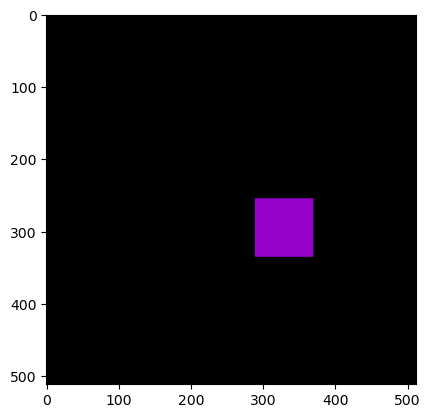

In [18]:
# 1. Click-to-move square
# Draw a fixed-size square on the canvas. On every left click, move the square 
# so its center is at the clicked point (redraw the canvas each time — don't 
# leave old squares behind)


import cv2
import numpy as np
import matplotlib.pyplot as plt

canvas = np.zeros((512, 512, 3), dtype=np.uint8)
cv2.rectangle(canvas, (230, 230), (270, 270), (200, 0, 150), -1)

def square_mover(event, x, y, flags, params):
    global canvas
    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
        canvas = np.zeros((512, 512, 3), dtype=np.uint8)
        cv2.rectangle(canvas, (x - 40, y - 40), (x + 40, y + 40), (200, 0, 150), -1)
             
cv2.namedWindow("Window1")
cv2.setMouseCallback("Window1", square_mover)

while True:
    cv2.imshow("Window1", canvas)
    if cv2.waitKey(1) & 0xff == 27:
        break
cv2.destroyAllWindows()
plt.imshow(canvas[..., ::-1])
plt.show()

Distance:  326.02453895374197
Distance:  435.5835166761938


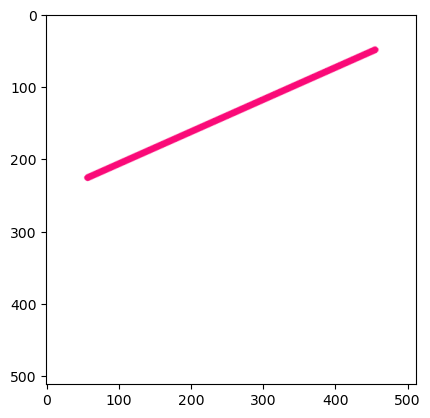

In [33]:
# 2. Distance measurer  
# On the first left click, store the point. On the second left click, draw a 
# line between the two points and print the pixel distance between them 
# (use `math.hypot` or the Euclidean formula). Reset after each pair of clicks 
# so the user can measure again.

import cv2
import numpy as np
import matplotlib.pyplot as plt


point = None
first_click = True
canvas = np.ones((512, 512, 3), dtype=np.uint8) * 255
def compute_distance(event, x, y, flags, params):
    global first_click, point, canvas
    if event == cv2.EVENT_LBUTTONDOWN and first_click:
        canvas = np.ones((512, 512, 3), dtype=np.uint8) * 255
        point = (x, y)
        first_click = False
        
    elif event == cv2.EVENT_LBUTTONDOWN and not first_click:
        cv2.line(canvas, point, (x, y), (120, 10, 250), 8, lineType=cv2.LINE_AA)
        distance = np.sqrt(((x - point[0]) ** 2) + ((y - point[1]) ** 2))
        print("Distance: ", distance)
        first_click = True
        
        
cv2.namedWindow("Window2")
cv2.setMouseCallback("Window2", compute_distance)

while True:
    cv2.imshow("Window2", canvas)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break
cv2.destroyAllWindows()

plt.imshow(canvas[..., ::-1])
plt.show()

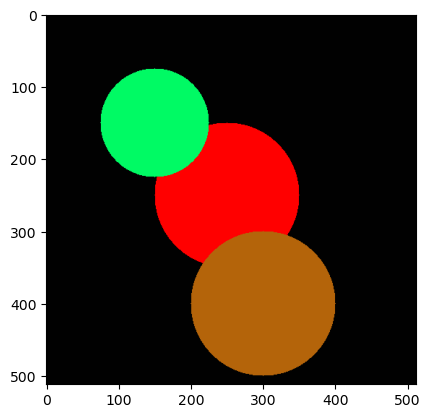

In [34]:
# 3. Hover highlight 
# Draw 3 fixed circles on the canvas at different positions. As the mouse moves, 
# detect whether the cursor is currently *inside* any circle (compare distance 
# from cursor to circle center against the radius) and redraw that circle in a 
# different color while hovered — reverting when the cursor leaves.

import cv2
import numpy as np
import matplotlib.pyplot as plt


canvas = np.ones((512, 512, 3), dtype=np.uint8)
centers = [(250, 250), (150, 150), (300, 400)]
radiuses = [100, 75, 100]
colors = [(220, 0, 160), (100, 250, 0), (10, 100, 180)]

for center, radius, color in zip(centers, radiuses, colors):
    cv2.circle(canvas, center, radius, color, -1)
    
def circle_detector(event, x, y, flags, params):
    global  centers, radiuses, colors, canvas
    if event == cv2.EVENT_MOUSEMOVE:
        distances = []
        for i in range(3):
            distance = np.sqrt(((x - centers[i][0]) ** 2) + ((y - centers[i][1]) ** 2))
            distances.append(distance)
        for i in range(3):
            if distances[i] < radiuses[i]:
                cv2.circle(canvas, centers[i], radiuses[i], (0, 0, 255), -1)
            if distances[i] > radiuses[i]:
                cv2.circle(canvas, centers[i], radiuses[i], colors[i], -1)
        
cv2.namedWindow("Window3")
cv2.setMouseCallback("Window3", circle_detector)

while True:
    cv2.imshow("Window3", canvas)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break
cv2.destroyAllWindows()

plt.imshow(canvas[..., ::-1])
plt.show()

In [16]:
# 4. Right-click context menu (simulated)
# On right-click, print a small text "menu" to the console with 3 options 
# (e.g. "1: Red  2: Green  3: Blue"). Then use a keyboard press (`'1'`, `'2'`, `'3'`) 
# to actually change the drawing color, confirming your choice by printing which 
# color is now active.

import cv2
import numpy as np
import matplotlib.pyplot as plt

def choose_color(event, x, y, flags, params):
    menu = """
    Choose an option
    -----------------
    1. Blue
    2. Green
    3. Red
    """
    if event == cv2.EVENT_RBUTTONDOWN:
        print(menu)

canvas = np.zeros((512, 512, 3), np.uint8)
cv2.namedWindow("Window4")
cv2.setMouseCallback("Window4", choose_color)

while True:
    cv2.imshow("Window4", canvas)
    key = cv2.waitKey(2) & 0xff
    if key == ord("1"):
        print("Blue")
        break
    elif key == ord("2"):
        print("Green")
        break
    elif key == ord("3"):
        print("Red")
        break
    elif key == ord("q"):
        break
cv2.destroyAllWindows()


    Choose an option
    -----------------
    1. Blue
    2. Green
    3. Red
    
Red


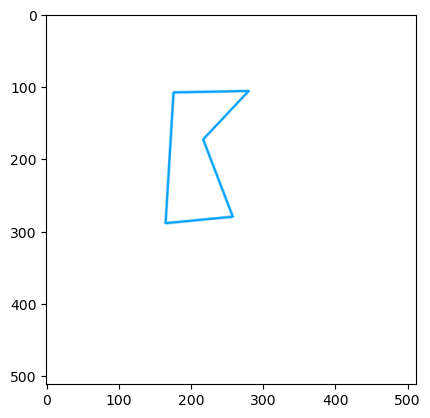

In [46]:
# 5. Multi-point polygon drawer 
# Each left click adds a new point to a list. After every click, redraw the 
# canvas connecting all points so far with lines (`cv2.polylines`). On right-click, 
# close the polygon (connect the last point back to the first) and stop accepting 
# new points until `'c'` is pressed to clear and start over.

import cv2
import numpy as np
import matplotlib.pyplot as plt

canvas = np.ones((512, 512, 3), dtype=np.uint8)
vertices = []
accepting = True

COLOR = (250, 160, 0)
THICKNESS = 2

def get_points_array():
    return np.array(vertices, dtype=np.int32).reshape(-1, 1, 2)

def redraw(closed=False):
    global canvas
    canvas[:] = 255
    if len(vertices) == 1:
        cv2.circle(canvas, vertices[0], 3, COLOR, -1)
    elif len(vertices) >= 2:
        cv2.polylines(canvas, [get_points_array()], closed, COLOR, THICKNESS, lineType=cv2.LINE_AA)

def draw_polygon(event, x, y, flags, params):
    global accepting

    if event == cv2.EVENT_LBUTTONDOWN and accepting:
        vertices.append((x, y))
        redraw(closed=False)

    elif event == cv2.EVENT_RBUTTONDOWN and accepting:
        accepting = False
        redraw(closed=True)

cv2.namedWindow("Window5")
cv2.setMouseCallback("Window5", draw_polygon)

while True:
    cv2.imshow("Window5", canvas)
    key = cv2.waitKey(1) & 0xFF

    if key == ord("c"):
        vertices.clear()
        accepting = True
        canvas[:] = 255
    if key == ord("q"):
        break

cv2.destroyAllWindows()

plt.imshow(canvas[..., ::-1])
plt.show()

## **Under the Hood — What Actually Happens**

It's worth knowing precisely what's going on, because it explains a lot of 
"weird" behavior beginners hit.

1. OpenCV's window is drawn using your OS's native GUI backend (Win32, Cocoa, 
   GTK, Qt — depending on your platform and OpenCV build).
2. That backend continuously listens for OS-level input events (this happens 
   in C++, outside Python's control).
3. `cv2.setMouseCallback()` registers your Python function as a **hook** — 
   OpenCV's C++ layer stores a reference to it.
4. **Critically: this hook is only *checked* when you call `cv2.waitKey()`.** 
   OpenCV's window system needs periodic "ticks" to process its event queue 
   (mouse, keyboard, window redraws) — `waitKey()` is what triggers that tick.
5. When a tick happens and a mouse event is pending, OpenCV pops it off the 
   queue and calls your Python callback with the event data.

**This is why a loop is mandatory** — without repeated calls to `waitKey()`, 
OpenCV never gets a chance to check for new mouse activity, and your callback 
simply never fires, even if the window is visibly open.

---

## **How imshow, waitKey, and setMouseCallback Connect**

These three work together as a single loop — think of it as a **heartbeat**:

```python
while True:
    cv2.imshow("Canvas", img)      # 1. Draw/refresh the current frame
    key = cv2.waitKey(1)           # 2. Pump the event queue (mouse + keyboard)
    if key & 0xFF == ord('q'):     # 3. Check for exit condition
        break
```

| Function | Role |
|---|---|
| `cv2.imshow()` | Renders the current image to the window. Doesn't process input. |
| `cv2.waitKey(ms)` | Pauses execution for `ms` milliseconds **and** processes the 
OS event queue during that pause — this is the only moment mouse callbacks can fire. |
| `cv2.setMouseCallback()` | Registers *what* to do when an event is found during 
that `waitKey` tick. |

**Analogy:** `setMouseCallback` is the alarm you set. `waitKey` is the moment 
you actually check the clock. If you never check the clock, the alarm never 
gets to go off — no matter how well you set it.

This is also why `cv2.waitKey(1)` (a small delay, called repeatedly) is used 
instead of `cv2.waitKey(0)` (waits forever for a keypress) in interactive apps — 
you need frequent ticks to catch mouse movement, not just a single keyboard check.

---

## **Reference: All Flags Types**

#### **Flags (the `flags` argument — bitwise, use `&` to check)**
| Constant | Meaning |
|---|---|
| `cv2.EVENT_FLAG_LBUTTON` / `RBUTTON` / `MBUTTON` | That button is currently held |
| `cv2.EVENT_FLAG_CTRLKEY` / `SHIFTKEY` / `ALTKEY` | That modifier key is currently held |

```python
if flags & cv2.EVENT_FLAG_SHIFTKEY:
    print("Shift held during this event")
```

For `EVENT_MOUSEWHEEL`, `flags` is signed, not a bitmask — check `flags > 0` (scroll up) 
vs `flags < 0` (scroll down).

---

## **Exercises**

Work through these in order — each builds on the previous one's pattern.

**1. Coordinate logger**  
Print `(x, y)` every time the mouse moves, but only when the left button 
is held down (i.e. simulate "drag tracking" with just print statements, no drawing yet).

**2. Click counter**  
Keep a running count of left clicks and right clicks separately. Display the 
count in the console after every click.

**3. Colored dot painter**  
Left click → draw a green filled circle. Right click → draw a red filled circle. 
Double-click (either button) → clear the entire canvas.

**4. Live rectangle preview**  
Recreate the drag-rectangle example from earlier, but make the rectangle's 
color change based on whether Shift is held (`cv2.EVENT_FLAG_SHIFTKEY`) while dragging.

**5. Pixel inspector**  
Load a real image. On mouse move (not click), continuously print the BGR 
pixel value under the cursor. Bonus: overlay this value as text on the image itself 
using `cv2.putText()`.

> 💡 Tip for all exercises: remember the `[y, x]` vs `(x, y)` indexing gotcha 
> when reading pixel values from a NumPy image array.

---

## **Mini Project: Build a Simple Paint App**

**Goal:** A small paint application supporting freehand drawing, brush color 
switching, and brush size adjustment.

**Requirements:**
1. Left-click-and-drag → draws a continuous line following the cursor (freehand).
2. Press `'r'`, `'g'`, `'b'` keys → switch brush color to red, green, blue.
3. Scroll wheel → increase/decrease brush thickness (`cv2.EVENT_MOUSEWHEEL`).
4. Press `'c'` → clear the canvas.
5. Press `'s'` → save the current canvas to disk as `painting.png`.
6. Press `'q'` → quit.

**Design hints:**
- You'll need a boolean state variable (e.g. `drawing`) toggled by 
  `LBUTTONDOWN`/`LBUTTONUP`, same pattern as the drag-rectangle example.
- Instead of drawing one shape, on every `EVENT_MOUSEMOVE` while `drawing` is 
  `True`, draw a small circle or a line segment from the *previous* point to 
  the *current* point — store the previous point in another state variable.
- Brush color and thickness should be stored in variables *outside* the callback, 
  modified by the keyboard handling in your main `waitKey` loop, and simply 
  *read* by the callback when drawing.

Try building this yourself before checking any reference solution — the goal is 
to get comfortable managing state across repeated callback invocations, which 
is the core skill this whole notebook is building toward.

---

## **Summary**

- A **mouse event** is an OS-reported action (click, move, scroll) that OpenCV 
  exposes as an integer constant.
- **Event-driven programming** means your code reacts to events instead of 
  running top-to-bottom — you write handlers, not sequences.
- A **callback** is a function you hand off to OpenCV; OpenCV calls it for you, 
  always with the fixed signature `(event, x, y, flags, param)`.
- `cv2.setMouseCallback()` registers the callback — but it only *fires* when 
  `cv2.waitKey()` runs, because that's the moment OpenCV processes its OS event 
  queue. `imshow` just renders; it doesn't listen.
- Most real interactions (drawing, cropping, dragging) require **state variables** 
  outside the callback, since each call is otherwise stateless on its own.

### Common Pitfalls Recap
| Symptom | Likely Cause |
|---|---|
| Callback never fires | Missing `waitKey` loop, or `setMouseCallback` called before `namedWindow` |
| Drawing leaves "trails" during drag | Forgot to `img.copy()` before previewing each frame |
| Wrong pixel read | Mixed up `(x, y)` mouse coords with `[row, col]` = `[y, x]` NumPy indexing |
| Wheel direction check fails | Treated `flags` as a bitmask instead of a signed value |

Next steps: try combining mouse events with `cv2.selectROI()` alternatives, 
or extend the paint app to support undo (`'z'` key) by storing a snapshot 
stack of the canvas after each stroke.